In [ ]:
# from pyspark.sql import SparkSession

# spark = SparkSession.builder.appName("ArbresRemarquables").getOrCreate()
# sc = spark.sparkContext  # ← obligatoire pour utiliser sc.parallelize()

# # Données fictives
# data = [
#     {"nom": "Chêne",   "annee": "1800", "hauteur": "15", "arrond": "75001"},
#     {"nom": "Tilleul", "annee": "Inconnue", "hauteur": "10", "arrond": "75002"},
#     {"nom": "Platane", "annee": "1950", "hauteur": None,  "arrond": "75001"},
#     {"nom": "Hêtre",   "annee": "1600", "hauteur": "20", "arrond": "75003"},
#     {"nom": "Sapin",   "annee": None,   "hauteur": "8",  "arrond": "75002"},
# ]

# rdd_test = sc.parallelize(data)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/17 10:18:38 WARN Utils: Your hostname, PYTHON-08, resolves to a loopback address: 127.0.1.1; using 172.22.114.75 instead (on interface eno1)
26/04/17 10:18:38 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/17 10:18:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
# # ── ÉTAPE 2 : filter ────────────────────────────────────────────────────────
# # On garde uniquement les lignes avec une année valide
# def annee_valide(row):
#     val = row["annee"]
#     if val is None:
#         return False
#     try:
#         int(val)
#         return True
#     except (ValueError, TypeError):
#         return False

# rdd_filtre = rdd_test.filter(annee_valide)

# print("=== Après filter (annee valide) ===")
# for row in rdd_filtre.collect():
#     print(row)
# # → Tilleul et Sapin ont disparu

=== Après filter (annee valide) ===


{'nom': 'Chêne', 'annee': '1800', 'hauteur': '15', 'arrond': '75001'}
{'nom': 'Platane', 'annee': '1950', 'hauteur': None, 'arrond': '75001'}
{'nom': 'Hêtre', 'annee': '1600', 'hauteur': '20', 'arrond': '75003'}


In [ ]:
# # ── ÉTAPE 3 : map ───────────────────────────────────────────────────────────
# # On transforme chaque ligne en un simple âge
# rdd_ages = rdd_filtre.map(lambda row: 2026 - int(row["annee"]))

# print("=== Après map (calcul âge) ===")
# print(rdd_ages.collect())

=== Après map (calcul âge) ===
[226, 76, 426]


In [ ]:
# # ── ÉTAPE 4 : reduce ────────────────────────────────────────────────────────
# # On garde le maximum
# age_max = rdd_ages.reduce(lambda a, b: a if a > b else b)

# print("=== Après reduce (max) ===")
# print(f"Âge max : {age_max} ans")

=== Après reduce (max) ===
Âge max : 426 ans


In [ ]:
# # ── ÉTAPE 5 : map en tuple + reduceByKey ────────────────────────────────────
# # Pour compter les arbres par arrondissement
# rdd_arrond = rdd_test.map(lambda row: (row["arrond"], 1))

# print("=== Après map en tuple ===")
# print(rdd_arrond.collect())

# rdd_compte = rdd_arrond.reduceByKey(lambda a, b: a + b)

# print("=== Après reduceByKey ===")
# print(rdd_compte.collect())


=== Après map en tuple ===
[('75001', 1), ('75002', 1), ('75001', 1), ('75003', 1), ('75002', 1)]
=== Après reduceByKey ===
[('75001', 2), ('75003', 1), ('75002', 2)]


In [ ]:
# from pyspark.sql import SparkSession
# from pyspark.sql.functions import col, sum as spark_sum

# spark = SparkSession.builder.appName("Taxi").getOrCreate()
# sc = spark.sparkContext
# df = spark.read.parquet("yellow_tripdata_2026-01.parquet")
# df.show(10)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       2| 2026-01-01 00:54:04|  2026-01-01 00:59:37|              1|         0.97|         1|                 N|         239|    

In [ ]:
# df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [ ]:
# print(f"le nombre totale de lignes: {df.count()}")

le nombre totale de lignes: 3724889


In [ ]:
# df.select([spark_sum(col(c).isNull().cast("int")).alias(c) 
#            for c in df.columns]).show(vertical=True)

-RECORD 0------------------------
 VendorID              | 0       
 tpep_pickup_datetime  | 0       
 tpep_dropoff_datetime | 0       
 passenger_count       | 1088058 
 trip_distance         | 0       
 RatecodeID            | 1088058 
 store_and_fwd_flag    | 1088058 
 PULocationID          | 0       
 DOLocationID          | 0       
 payment_type          | 0       
 fare_amount           | 0       
 extra                 | 0       
 mta_tax               | 0       
 tip_amount            | 0       
 tolls_amount          | 0       
 improvement_surcharge | 0       
 total_amount          | 0       
 congestion_surcharge  | 1088058 
 Airport_fee           | 1088058 
 cbd_congestion_fee    | 0       



In [ ]:
# df.groupBy("VendorID").count().show()

+--------+-------+
|VendorID|  count|
+--------+-------+
|       1| 710425|
|       7|  44705|
|       2|2965742|
|       6|   4017|
+--------+-------+



In [ ]:
# from pyspark.sql.functions import col

# df.filter(col("passenger_count").isNull()).groupBy("VendorID").count().show()

+--------+------+
|VendorID| count|
+--------+------+
|       1|139406|
|       6|  4017|
|       2|944635|
+--------+------+



In [ ]:
# df_clean = df.fillna({
#     "passenger_count" : 1,
#     "RatecodeID": 1,               
#     "store_and_fwd_flag": "N",    
#     "congestion_surcharge": 0.0,   
#     "Airport_fee": 0.0

# })
# print(f"Nulls restants après fillna : {df_clean.filter(col('passenger_count').isNull()).count()}")

Nulls restants après fillna : 0


In [ ]:
# df_clean.filter(col("passenger_count").isNull()).groupBy("VendorID").count().show()

+--------+-----+
|VendorID|count|
+--------+-----+
+--------+-----+



In [ ]:
# print(f"Avant filtre : {df_clean.count()} lignes")

# df_clean = df_clean.filter(
#     (col("fare_amount") > 0) & (col("fare_amount") <= 500) &
#     (col("trip_distance") > 0) & (col("trip_distance") <= 200)
# )

# print(f"Après filtre aberrants : {df_clean.count()} lignes")

Avant filtre : 3560706 lignes
Après filtre aberrants : 3560706 lignes


In [62]:
#df_clean = df_clean.filter(
#    (col("fare_amount") <= 0) & (col("fare_amount") > 500) &
#    (col("trip_distance") == 0) & (col("trip_distance") > 200)
#)

#print(f"Après filtre aberrants : {df_clean.count()} lignes")

In [ ]:
# total = df.count()
# conserve = df_clean.count()
# print(f"Total initial     : {total} lignes")
# print(f"Total conservé    : {conserve} lignes")
# print(f"Lignes conservées : {conserve / total * 100:}%")

Total initial     : 3724889 lignes
Total conservé    : 3560706 lignes
Lignes conservées : 95.5922713401661%


In [ ]:
# # La plus chère
# df_clean.orderBy(col("fare_amount").desc()).select(
#     "fare_amount", "trip_distance", "tpep_pickup_datetime"
# ).show(1)

# # La plus longue
# df_clean.orderBy(col("trip_distance").desc()).select(
#     "fare_amount", "trip_distance", "tpep_pickup_datetime"
# ).show(1)

+-----------+-------------+--------------------+
|fare_amount|trip_distance|tpep_pickup_datetime|
+-----------+-------------+--------------------+
|      500.0|         18.8| 2026-01-18 18:48:03|
+-----------+-------------+--------------------+
only showing top 1 row
+-----------+-------------+--------------------+
|fare_amount|trip_distance|tpep_pickup_datetime|
+-----------+-------------+--------------------+
|       33.5|        192.8| 2026-01-08 11:25:05|
+-----------+-------------+--------------------+
only showing top 1 row


# ITÉRATION 2 Spark avancé – Cluster & Performances

### 1 – Lire le Parquet et mesurer le temps

In [1]:
from pyspark.sql import SparkSession
import time
spark = SparkSession.builder.appName("Taxi_kit2").getOrCreate()
start = time.time()
df = spark.read.parquet("yellow_tripdata_2026-01.parquet")
df.count()  # force la lecture complète
end = time.time()

print(f"Temps lecture Parquet : {end - start:.2f} secondes")
print(f"Nombre de lignes : {df.count()}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/17 16:06:58 WARN Utils: Your hostname, PYTHON-08, resolves to a loopback address: 127.0.1.1; using 172.22.114.75 instead (on interface eno1)
26/04/17 16:06:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/17 16:06:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Temps lecture Parquet : 3.55 secondes
Nombre de lignes : 3724889


### 2 – Convertir en CSV

In [2]:
df.write.mode("overwrite").option("header", True).csv("yellow_tripdata_2026-01_CSV")
print("Export CSV terminé")

Export CSV terminé


### 3 – Lire le CSV et comparer

In [3]:
start = time.time()
df_csv = spark.read.option("header", True).option("inferSchema", True).csv("yellow_tripdata_2026-01_CSV")
df_csv.count()
end = time.time()

print(f"Temps lecture CSV : {end - start:.2f} secondes")

Temps lecture CSV : 4.66 secondes


### 4 – Projection : lire uniquement 3 colonnes

In [4]:
colonnes = ["fare_amount", "trip_distance", "total_amount"]

# Depuis Parquet
start = time.time()
df_parquet_proj = spark.read.parquet("yellow_tripdata_2026-01.parquet").select(colonnes)
df_parquet_proj.count()
end = time.time()
print(f"Parquet 3 colonnes : {end - start:.2f} secondes")

# Depuis CSV
start = time.time()
df_csv_proj = spark.read.option("header", True).option("inferSchema", True).csv("yellow_tripdata_2026-01_CSV").select(colonnes)
df_csv_proj.count()
end = time.time()
print(f"CSV 3 colonnes : {end - start:.2f} secondes")

Parquet 3 colonnes : 0.29 secondes


CSV 3 colonnes : 3.75 secondes


### Pandas vs Spark pour lire CSV

In [5]:
import pandas as pd
import time

# Pandas - Parquet
start = time.time()
df_pd = pd.read_parquet("yellow_tripdata_2026-01.parquet")
end = time.time()
print(f"Pandas Parquet : {end - start:.2f} secondes")

# df_pd.to_csv("yellow_tripdata_2026-01.csv")
# Pandas - CSV (après export)
start = time.time()
# df_pd_csv = pd.read_csv("yellow_tripdata_2026-01_CSV/part-00000-b341c75e-504a-4498-855e-4c8d798370ed-c000.csv")  # un seul fichier
df_pd_csv = pd.read_csv("yellow_tripdata_2026-01.csv")
end = time.time()
print(f"Pandas CSV : {end - start:.2f} secondes")

Pandas Parquet : 0.32 secondes


/tmp/ipykernel_73102/622122278.py:14: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pd_csv = pd.read_csv("yellow_tripdata_2026-01.csv")


Pandas CSV : 7.73 secondes


# 2.2 – Architecture cluster etlien avec Lambda

In [13]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TaxiCluster") \
    .master("spark://localhost:7077") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

print(spark.sparkContext.master)

local[*]


# 2.4 – Partitionnement et montée en charge

### 12. Afficher le nombre de partitions : rdd.getNumPartitions()

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Partitions").master("local[*]").getOrCreate()
sc = spark.sparkContext

df = spark.read.parquet("/home/youssef.hirchaou@Digital-Grenoble.local/campus/Big_data_architecture_distribuées/yellow_tripdata_2026-01.parquet")
rdd = df.rdd

print(f"Nombre de partitions par défaut : {rdd.getNumPartitions()}")

Nombre de partitions par défaut : 8


### 13 – repartition vs coalesce

In [ ]:
import time

# repartition → shuffle complet (redistribution totale)
start = time.time()
rdd_repart = rdd.repartition(16)
rdd_repart.count()
end = time.time()
print(f"repartition(16) : {rdd_repart.getNumPartitions()} partitions | {end-start:.2f}s")

# coalesce → pas de shuffle (fusionne juste les partitions existantes)
start = time.time()
rdd_coal = rdd.coalesce(4)
rdd_coal.count()
end = time.time()
print(f"coalesce(4)     : {rdd_coal.getNumPartitions()} partitions | {end-start:.2f}s")

repartition(16) : 16 partitions | 23.07s


coalesce(4)     : 4 partitions | 9.82s


26/04/20 13:46:39 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 3673561 ms exceeds timeout 120000 ms
26/04/20 13:46:39 WARN SparkContext: Killing executors is not supported by current scheduler.
26/04/20 13:46:44 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

### 14 – Impact du nombre de partitions sur l'agrégation

In [ ]:
from pyspark.sql.functions import avg, count

resultats = []

for n in [2, 4, 8, 16, 32, 64]:
    rdd_test = rdd.repartition(n)
    start = time.time()
    rdd_test.map(lambda r: (r["PULocationID"], (r["fare_amount"] or 0, 1))) \
            .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1])) \
            .collect()
    end = time.time()
    resultats.append((n, round(end-start, 2)))
    print(f"Partitions: {n:3d} | Temps: {end-start:.2f}s")

print("\nRésumé :")
print(f"{'Partitions':<15} {'Temps (s)':<10}")
for n, t in resultats:
    print(f"{n:<15} {t:<10}")

26/04/20 13:48:14 WARN Executor: Issue communicating with driver in heartbeater]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:356)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.scala:18)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:194

Partitions:   2 | Temps: 25.46s


26/04/20 13:48:34 ERROR Inbox: Ignoring error                       (4 + 4) / 8]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apach

Partitions:   4 | Temps: 22.46s


26/04/20 13:48:54 ERROR Inbox: Ignoring error                       (4 + 4) / 8]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apach

...

26/04/20 13:49:44 WARN Executor: Issue communicating with driver in heartbeater]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:356)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.scala:18)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:194

Partitions:  32 | Temps: 23.72s


26/04/20 13:50:04 ERROR Inbox: Ignoring error                       (4 + 4) / 8]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apach

Partitions:  64 | Temps: 24.28s

Résumé :
Partitions      Temps (s) 
2               25.46     
4               22.46     
8               22.24     
16              22.6      
32              23.72     
64              24.28     


26/04/20 13:50:34 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:356)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.scala:18)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1941

### 15 – Jeux de données croissants

In [5]:
# 1 mois  → 100% du fichier
# 3 mois  → 3x le fichier
# 6 mois  → 6x le fichier
# 12 mois → 12x le fichier

df_1mois  = df
df_3mois  = df.union(df).union(df)
df_6mois  = df_3mois.union(df_3mois)
df_12mois = df_6mois.union(df_6mois)

print(f"1 mois  : {df_1mois.count():>10} lignes")
print(f"3 mois  : {df_3mois.count():>10} lignes")
print(f"6 mois  : {df_6mois.count():>10} lignes")
print(f"12 mois : {df_12mois.count():>10} lignes")

1 mois  :    3724889 lignes
3 mois  :   11174667 lignes
6 mois  :   22349334 lignes
12 mois :   44698668 lignes


26/04/20 13:50:54 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apache.spark.storage.BlockManagerMasterE

### 16 – Mesurer nb lignes, temps, RAM

In [6]:
import psutil

def job_agregation(df, label):
    process = psutil.Process()
    mem_avant = process.memory_info().rss / 1024**2  # MB

    start = time.time()
    nb_lignes = df.count()
    df.rdd \
      .map(lambda r: (r["PULocationID"], (r["fare_amount"] or 0, 1))) \
      .reduceByKey(lambda a, b: (a[0]+b[0], a[1]+b[1])) \
      .collect()
    end = time.time()

    mem_apres = process.memory_info().rss / 1024**2

    return {
        "label": label,
        "lignes": nb_lignes,
        "temps": round(end - start, 2),
        "ram_mb": round(mem_apres - mem_avant, 2)
    }

resultats = []
resultats.append(job_agregation(df_1mois,  "1 mois"))
resultats.append(job_agregation(df_3mois,  "3 mois"))
resultats.append(job_agregation(df_6mois,  "6 mois"))
resultats.append(job_agregation(df_12mois, "12 mois"))

print(f"\n{'Période':<10} {'Lignes':>12} {'Temps (s)':>12} {'RAM (MB)':>10}")
print("─" * 48)
for r in resultats:
    print(f"{r['label']:<10} {r['lignes']:>12} {r['temps']:>12} {r['ram_mb']:>10}")

26/04/20 13:51:04 ERROR Inbox: Ignoring error                       (4 + 4) / 8]
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apach


Période          Lignes    Temps (s)   RAM (MB)
────────────────────────────────────────────────
1 mois          3724889         11.1       0.02
3 mois         11174667        33.99       0.05
6 mois         22349334        68.47       0.09
12 mois        44698668       134.56       0.17


26/04/20 13:55:14 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:356)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.scala:18)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1941

### 17 & 18 – Courbe et analyse

  Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17

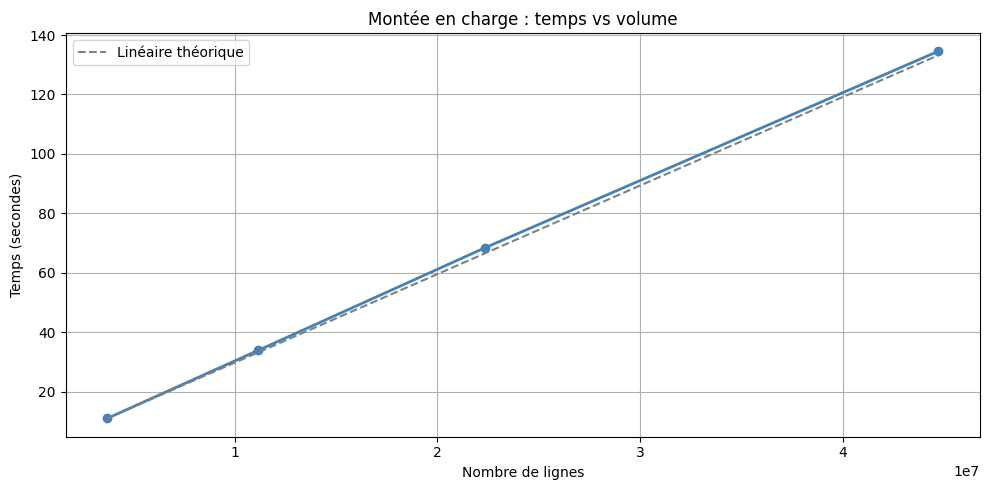

Courbe sauvegardée dans /tmp/courbe_charge.png


26/04/20 13:56:24 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at org.apache.spark.executor.Executor.$anonfun$heartbeater$1(Executor.scala:356)
	at scala.runtime.java8.JFunction0$mcV$sp.apply(JFunction0$mcV$sp.scala:18)
	at org.apache.spark.util.Utils$.logUncaughtExceptions(Utils.scala:1941

In [8]:
import subprocess
subprocess.run(["pip", "install", "matplotlib", "--break-system-packages"])
import matplotlib.pyplot as plt

volumes = [r["lignes"] for r in resultats]
temps   = [r["temps"]  for r in resultats]

plt.figure(figsize=(10, 5))
plt.plot(volumes, temps, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Nombre de lignes")
plt.ylabel("Temps (secondes)")
plt.title("Montée en charge : temps vs volume")

# Ligne de référence linéaire
import numpy as np
x = np.array(volumes)
plt.plot(x, x * temps[0]/volumes[0], '--', color='gray', label='Linéaire théorique')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/tmp/courbe_charge.png")
plt.show()
print("Courbe sauvegardée dans /tmp/courbe_charge.png")

In [ ]:
# Sub-linéaire  → cluster scale bien, overhead fixe amorti
# Linéaire      → performances proportionnelles au volume
# Supra-linéaire → goulot d'étranglement (mémoire, réseau, shuffle)